## 1. Environment setup
1. Install required libraries
2. Connect with MongoDB Atalas cluster
3. Define global constants

### 1.1 Install required libraries

In [ ]:
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.0 MB/s eta 0:00:00


### 1.2 Connect with MongoDB Atalas cluster
Use Google Colab **secrets** to store auth credentials.

Secret values are loaded read using `userdata.get('secret_name')`

In Google Colab, define the following Secrets:
- `MONGO_ATLAS_USER`
- `MONGO_ATLAS_PASSWORD`
- `MONGO_ATLAS_CLUSTER`
- `MONGO_ATLAS_HOST`


In [ ]:
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi
from google.colab import userdata

user = userdata.get('MONGO_ATLAS_USER')
password = userdata.get('MONGO_ATLAS_PASSWORD')
cluster = userdata.get('MONGO_ATLAS_CLUSTER')
host = userdata.get('MONGO_ATLAS_HOST')

uri = f"mongodb+srv://{user}:{password}@{cluster}.{host}/?retryWrites=true&w=majority&appName={cluster}"
# Create a new client and connect to the server
client = MongoClient(uri, server_api=ServerApi('1'))

# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)

del user, password, cluster, host, uri

Pinged your deployment. You successfully connected to MongoDB!


### 1.3 Define global constants

In [ ]:
# Constants
DATASET_AUTHOR = "victorsoeiro"
DATASET_NAME = "netflix-tv-shows-and-movies"

DATASET = f"{DATASET_AUTHOR}/{DATASET_NAME}"
ZIP_NAME = f"{DATASET_NAME}.zip"
DATA_DIR = "/content/data"

CREDITS = "credits"
TITLES = "titles"

CREDITS_CSV = f"{DATA_DIR}/{CREDITS}.csv"
TITLES_CSV  = f"{DATA_DIR}/{TITLES}.csv"

DB_NAME = "netflix-tv-shows-and-movies"

---

## 2. Create Database and Collections

In [ ]:
!pip install kaggle

### 2.1 Download the dataset
To downloaded the dataset use the Kaggle API (kaggle-cli) in a Google Colab environment.

Dataset: https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies

Steps required to use Kaggle API:
1. Create a free account at: https://www.kaggle.com/
2. Go to the account settings page: https://www.kaggle.com/settings
3. Generate a new API Token (or use an existing one).
4. In Google Colab, define the following Secrets:
    - `KAGGLE_USER` - Kaggle account username
    - `KAGGLE_KEY` - generated API key


In [ ]:
# Generate kaggle.json file
from google.colab import userdata
import json
import os

KAGGLE_DIR = "/root/.kaggle"
KAGGLE_API_TOKEN_FILE = f"{KAGGLE_DIR}/kaggle.json"

kaggle_creds = {
    "username": userdata.get('KAGGLE_USER'),
    "key": userdata.get('KAGGLE_KEY')
}

os.makedirs(KAGGLE_DIR, exist_ok=True)

with open(KAGGLE_API_TOKEN_FILE, "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(KAGGLE_API_TOKEN_FILE, 0o600)

del kaggle_creds

print(f"✓ File '{KAGGLE_API_TOKEN_FILE}' created successfully!")

✓ File '/root/.kaggle/kaggle.json' created successfully!


Download and unzip dataset files

In [ ]:
# Change directory to /content
%cd /content

# Create "data" if doesn't exist
import os
if not os.path.exists("data"):
    os.mkdir("data")
    print(f"📁 Directory '{DATA_DIR}' created successfully.")
else:
    print(f"📂 Directory '{DATA_DIR}' already exists.")

# Change directory to /data
%cd $DATA_DIR

# Download the dataset from z Kaggle (using kaggle-cli)
!kaggle datasets download -d $DATASET

# Unzip downloaded dataset
!unzip -o $ZIP_NAME

# List downloaded dataset files
!ls

/content
📁 Directory '/content/data' created successfully.
/content/data
Dataset URL: https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies
License(s): CC0-1.0
  0% 0.00/2.25M [00:00<?, ?B/s]
100% 2.25M/2.25M [00:00<00:00, 799MB/s]
Archive:  netflix-tv-shows-and-movies.zip
  inflating: credits.csv             
  inflating: titles.csv              
credits.csv  netflix-tv-shows-and-movies.zip  titles.csv


### 2.2 Create collections
Create a new database and collections using the previously established MongoDB client connection.

Database:
- `netflix-tv-shows-and-movies`

Collections:
- `credits`
- `titles`

In [ ]:
import pandas as pd
from pymongo import MongoClient
from pymongo.server_api import ServerApi

db = client[DB_NAME]

if CREDITS not in db.list_collection_names():
    db.create_collection(CREDITS)

if TITLES not in db.list_collection_names():
    db.create_collection(TITLES)

### 2.3 Insert data into collections

#### Collection 1: `titles`

##### **Step 1** (`titles` insert): Inspect `titles.csv` structure

In [ ]:
import pandas as pd

# Load CSV file
titles_df = pd.read_csv(TITLES_CSV)

print("CSV file loaded successfully")
print("DataFrame shape (rows, columns):", titles_df.shape)

print("\nColumns:")
print(list(titles_df.columns))

print("\nData types:")
print(titles_df.dtypes)

print("\nPreview (first 5 rows):")
display(titles_df.head())

print("\nMissing values per column:")
print(titles_df.isna().sum().sort_values(ascending=False))

CSV file loaded successfully
DataFrame shape (rows, columns): (5850, 15)

Columns:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

Data types:
id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                 float64
imdb_id                  object
imdb_score              float64
imdb_votes              float64
tmdb_popularity         float64
tmdb_score              float64
dtype: object

Preview (first 5 rows):


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600



Missing values per column:
seasons                 3744
age_certification       2619
imdb_votes               498
imdb_score               482
imdb_id                  403
tmdb_score               311
tmdb_popularity           91
description               18
title                      1
id                         0
type                       0
runtime                    0
release_year               0
genres                     0
production_countries       0
dtype: int64


##### **Step 2** (`titles` insert): Clean `titles_df`

In [ ]:
import ast
import math
import numpy as np

# Replace all NaN / numpy.nan with None (MongoDB-safe)
titles_df = titles_df.replace({np.nan: None})

# Convert stringified lists to real Python lists
titles_df["genres"] = titles_df["genres"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

titles_df["production_countries"] = titles_df["production_countries"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


# Convert DataFrame to list of documents
titles_docs = []
for record in titles_df.to_dict("records"):
    # Seasons apply only to SHOW
    if record.get("type") == "MOVIE":
        record["seasons"] = None
    else:
        if record.get("seasons") is not None:
            record["seasons"] = int(record["seasons"])

    titles_docs.append(record)


print("Titles data cleaning completed successfully")

print("\nSample cleaned document:")
print(titles_docs[1])

Titles data cleaning completed successfully

Sample cleaned document:
{'id': 'tm84618', 'title': 'Taxi Driver', 'type': 'MOVIE', 'description': 'A mentally unstable Vietnam War veteran works as a night-time taxi driver in New York City where the perceived decadence and sleaze feed his urge for violent action.', 'release_year': 1976, 'age_certification': 'R', 'runtime': 114, 'genres': ['drama', 'crime'], 'production_countries': ['US'], 'seasons': None, 'imdb_id': 'tt0075314', 'imdb_score': 8.2, 'imdb_votes': 808582.0, 'tmdb_popularity': 40.965, 'tmdb_score': 8.179}


##### **Step 3** (`titles` insert): Insert documents

In [ ]:
import time

# Select collection
titles_col = db[TITLES]

# Remove existing documents (optional but recommended)
titles_col.delete_many({})

# Measure insert time
start_time = time.perf_counter()

# Insert all documents into MongoDB
result = titles_col.insert_many(titles_docs)

end_time = time.perf_counter()

elapsed_time = end_time - start_time

print("Full insert completed successfully")
print("Number of inserted documents:", len(result.inserted_ids))
print(f"Insert time (seconds): {elapsed_time:.4f}")

Full insert completed successfully
Number of inserted documents: 5850
Insert time (seconds): 8.2864


#### Collection 2: `credits`

##### **Step 1** (`credits` insert): Inspect `credits.csv` structure

In [ ]:
import pandas as pd

# Load CSV file
credits_df = pd.read_csv(CREDITS_CSV)

print("CSV file loaded successfully")
print("DataFrame shape (rows, columns):", credits_df.shape)

print("\nColumns:")
print(list(credits_df.columns))

print("\nData types:")
print(credits_df.dtypes)

print("\nPreview (first 5 rows):")
display(credits_df.head())

print("\nMissing values per column:")
print(credits_df.isna().sum().sort_values(ascending=False))

CSV file loaded successfully
DataFrame shape (rows, columns): (77801, 5)

Columns:
['person_id', 'id', 'name', 'character', 'role']

Data types:
person_id     int64
id           object
name         object
character    object
role         object
dtype: object

Preview (first 5 rows):


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR



Missing values per column:
character    9772
person_id       0
id              0
name            0
role            0
dtype: int64


##### **Step 2** (`credits` insert): Clean `credits_df`

In [ ]:
import numpy as np

# Replace NaN / numpy.nan with None (MongoDB-safe)
credits_df = credits_df.replace({np.nan: None})

print("Credits data cleaning completed successfully")

print("\nSample cleaned document:")
print(credits_df.iloc[0].to_dict())

print("\nMissing values check (should be None, not NaN):")
print(credits_df.isna().sum())

Credits data cleaning completed successfully

Sample cleaned document:
{'person_id': 3748, 'id': 'tm84618', 'name': 'Robert De Niro', 'character': 'Travis Bickle', 'role': 'ACTOR'}

Missing values check (should be None, not NaN):
person_id       0
id              0
name            0
character    9772
role            0
dtype: int64


##### **Step 3** (`credits` insert): Insert documents

In [ ]:
# Prepare MongoDB-ready documents for credits
credits_docs = credits_df.to_dict("records")

print("Documents prepared for MongoDB insert")
print("Sample document:")
print(credits_docs[0])

Documents prepared for MongoDB insert
Sample document:
{'person_id': 3748, 'id': 'tm84618', 'name': 'Robert De Niro', 'character': 'Travis Bickle', 'role': 'ACTOR'}


In [ ]:
import time

# Select collection
credits_col = db[CREDITS]

# Remove existing documents (recommended to avoid duplicates)
credits_col.delete_many({})

# Convert DataFrame to list of documents
credits_docs = credits_df.to_dict("records")

# Measure insert time
start_time = time.perf_counter()

# Insert all documents into MongoDB
result = credits_col.insert_many(credits_docs)

end_time = time.perf_counter()

elapsed_time = end_time - start_time

print("Full insert completed successfully")
print("Number of inserted documents:", len(result.inserted_ids))
print(f"Insert time (seconds): {elapsed_time:.4f}")

Full insert completed successfully
Number of inserted documents: 77801
Insert time (seconds): 16.1469


## 3. Data Visualisation

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import numpy as np

### 3.1 `titles` collection charts

In [ ]:
db = client[DB_NAME]

# Select collections
titles_col = db[TITLES]
credits_col = db[CREDITS]

titles_col.count_documents({})
credits_col.count_documents({})

77801

Top 10 krajów produkcji

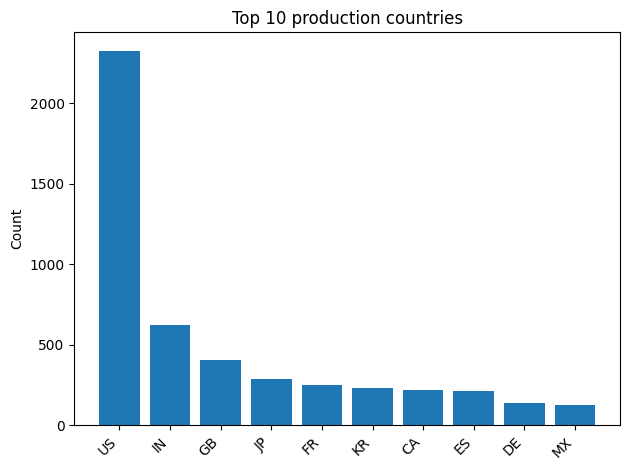

In [ ]:
docs = list(db.titles.find({}, {"_id": 0, "production_countries": 1}))
countries = []
for d in docs:
    if d.get("production_countries"):
        countries.extend(d["production_countries"])

top = Counter(countries).most_common(10)
labels, values = zip(*top) if top else ([], [])

plt.figure()
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Top 10 production countries")
plt.tight_layout()
plt.show()

Top 10 gatunków

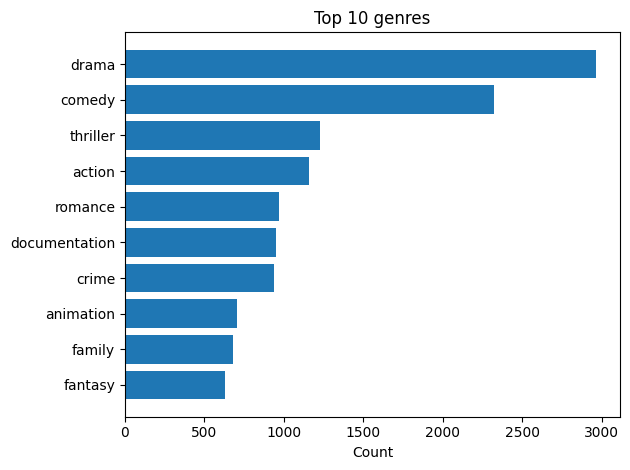

In [ ]:
docs = list(db.titles.find({}, {"_id": 0, "genres": 1}))
g = []
for d in docs:
    if d.get("genres"):
        g.extend(d["genres"])

top = Counter(g).most_common(10)
labels, values = zip(*top)

plt.figure()
plt.barh(labels[::-1], values[::-1])
plt.xlabel("Count")
plt.title("Top 10 genres")
plt.tight_layout()
plt.show()

Procentowa różnica w ilości filmów a seriali na patformie

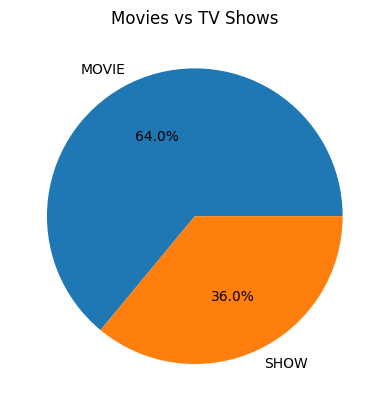

In [ ]:
types = list(db.titles.find({}, {"_id": 0, "type": 1}))
df_types = pd.DataFrame(types)

type_counts = df_types["type"].value_counts()

plt.figure()
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%")
plt.title("Movies vs TV Shows")
plt.show()


Zależność pomiędzy liczbą tytułów a średnim czasem trwania produkcji dla wybranych krajów.

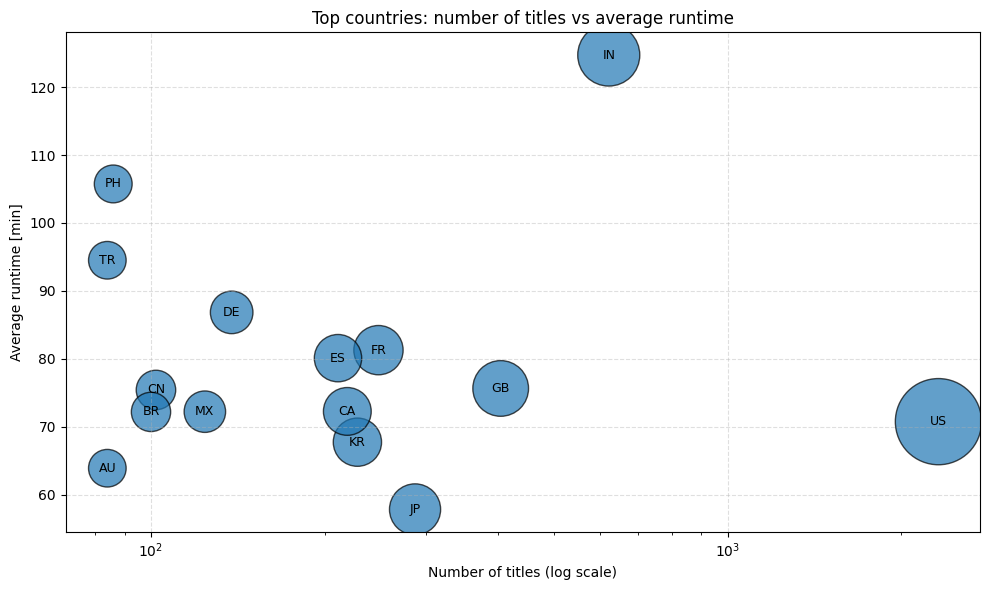

In [ ]:
#1
docs = list(db.titles.find(
    {},
    {"_id": 0, "production_countries": 1, "runtime": 1}
))

data = defaultdict(list)

for d in docs:
    if d.get("production_countries") and d.get("runtime"):
        for c in d["production_countries"]:
            data[c].append(d["runtime"])

rows = []
for country, runtimes in data.items():
    rows.append({
        "country": country,
        "count": len(runtimes),
        "avg_runtime": sum(runtimes) / len(runtimes)
    })

df = pd.DataFrame(rows)
# bierzemy tylko kraje z sensowną liczbą produkcji (żeby nie było szumu)
df = df[df["count"] >= 20]


#-----------------
#2
# sortujemy po liczbie tytułów
df_plot = df.sort_values("count", ascending=False)

# bierzemy np. top 15 krajów
df_plot = df_plot.head(15)

plt.figure(figsize=(10, 6))

sizes = np.sqrt(df_plot["count"]) * 80  # lepsze skalowanie bąbli

plt.scatter(
    df_plot["count"],
    df_plot["avg_runtime"],
    s=sizes,
    alpha=0.7,
    edgecolors="black"
)

# podpisy tylko dla wybranych punktów
for _, row in df_plot.iterrows():
    plt.text(
        row["count"],
        row["avg_runtime"],
        row["country"],
        fontsize=9,
        ha="center",
        va="center"
    )

plt.xscale("log")  # KLUCZOWE
plt.xlabel("Number of titles (log scale)")
plt.ylabel("Average runtime [min]")
plt.title("Top countries: number of titles vs average runtime")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Wykres bąbelkowy przedstawia zależność pomiędzy liczbą tytułów a średnim czasem trwania produkcji dla wybranych krajów. Zastosowanie skali logarytmicznej na osi liczby tytułów pozwoliło na czytelne porównanie krajów o bardzo różnej liczebności produkcji. Widoczna jest dominacja USA i Indii pod względem liczby tytułów, przy jednoczesnych różnicach w średniej długości produkcji.

### 3.2 `credits` collection charts

In [ ]:
credits_df = pd.DataFrame(
    list(db.credits.find({}, {"_id": 0}))
)

type(credits_df)

pandas.core.frame.DataFrame

Top 10 aktorów

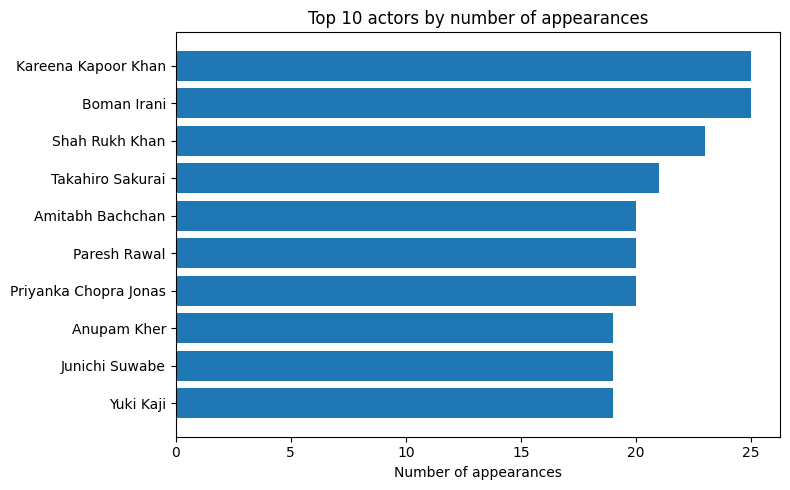

In [ ]:
actors = credits_df[credits_df["role"] == "ACTOR"]

top_actors = Counter(actors["name"]).most_common(10)
names, counts = zip(*top_actors)

plt.figure(figsize=(8, 5))
plt.barh(names[::-1], counts[::-1])
plt.xlabel("Number of appearances")
plt.title("Top 10 actors by number of appearances")
plt.tight_layout()
plt.show()

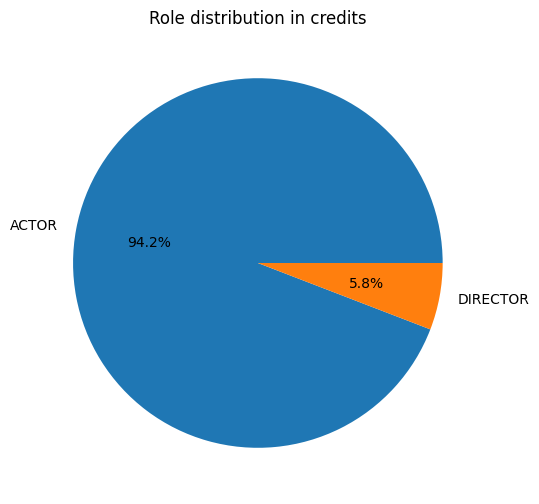

In [ ]:
role_counts = credits_df["role"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(role_counts, labels=role_counts.index, autopct="%1.1f%%")
plt.title("Role distribution in credits")
plt.show()

### 3.3 Join both collections (`titles` & `credits`)


#### Badanie powiązania między kolekcjami

In [ ]:
from pprint import pprint

# pobierz kilka przykładowych tytułów
sample_titles = list(
    titles_col.find(
        {},
        {"_id": 0, "id": 1, "title": 1, "type": 1}
    ).limit(5)
)

print("Przykładowe dokumenty z kolekcji titles:\n")
pprint(sample_titles)

print("\nSprawdzenie powiązanych rekordów w kolekcji credits:\n")

for t in sample_titles:
    title_id = t["id"]
    credits_count = credits_col.count_documents({"id": title_id})

    print(f"Tytuł: {t['title']}")
    print(f"ID: {title_id}")
    print(f"Liczba powiązanych rekordów w credits: {credits_count}")
    print("-" * 50)


Przykładowe dokumenty z kolekcji titles:

[{'id': 'ts300399',
  'title': 'Five Came Back: The Reference Films',
  'type': 'SHOW'},
 {'id': 'tm84618', 'title': 'Taxi Driver', 'type': 'MOVIE'},
 {'id': 'tm154986', 'title': 'Deliverance', 'type': 'MOVIE'},
 {'id': 'tm127384',
  'title': 'Monty Python and the Holy Grail',
  'type': 'MOVIE'},
 {'id': 'tm120801', 'title': 'The Dirty Dozen', 'type': 'MOVIE'}]

Sprawdzenie powiązanych rekordów w kolekcji credits:

Tytuł: Five Came Back: The Reference Films
ID: ts300399
Liczba powiązanych rekordów w credits: 0
--------------------------------------------------
Tytuł: Taxi Driver
ID: tm84618
Liczba powiązanych rekordów w credits: 37
--------------------------------------------------
Tytuł: Deliverance
ID: tm154986
Liczba powiązanych rekordów w credits: 23
--------------------------------------------------
Tytuł: Monty Python and the Holy Grail
ID: tm127384
Liczba powiązanych rekordów w credits: 48
------------------------------------------------

In [ ]:
pipeline = [
    {
        "$group": {
            "_id": "$id",
            "credits_count": {"$sum": 1}
        }
    }
]

credits_per_title = list(credits_col.aggregate(pipeline))

credits_map = {doc["_id"]: doc["credits_count"] for doc in credits_per_title}

total_titles = titles_col.count_documents({})
titles_with_credits = sum(
    1 for t in titles_col.find({}, {"_id": 0, "id": 1})
    if t["id"] in credits_map
)

print(f"Liczba tytułów w titles: {total_titles}")
print(f"Liczba tytułów z credits: {titles_with_credits}")
print(f"Odsetek powiązanych tytułów: {titles_with_credits / total_titles:.2%}")

if credits_map:
    values = list(credits_map.values())
    print(f"Średnia liczba credits: {sum(values) / len(values):.2f}")
    print(f"Maksymalna liczba credits: {max(values)}")


Liczba tytułów w titles: 5850
Liczba tytułów z credits: 5489
Odsetek powiązanych tytułów: 93.83%
Średnia liczba credits: 14.17
Maksymalna liczba credits: 208


#### Wizualizacja 1
Liczba rekordów credits vs typ produkcji (MOVIE / SHOW)

In [ ]:
import matplotlib.pyplot as plt

# agregacja credits -> liczba na tytuł
pipeline = [
    {
        "$group": {
            "_id": "$id",
            "credits_count": {"$sum": 1}
        }
    }
]

credits_counts = {
    doc["_id"]: doc["credits_count"]
    for doc in credits_col.aggregate(pipeline)
}

# pobranie typów z titles
movies_cast = []
shows_cast = []

for t in titles_col.find({}, {"_id": 0, "id": 1, "type": 1}):
    cid = t["id"]
    if cid in credits_counts:
        if t["type"] == "MOVIE":
            movies_cast.append(credits_counts[cid])
        elif t["type"] == "SHOW":
            shows_cast.append(credits_counts[cid])

/tmp/ipython-input-28763684.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


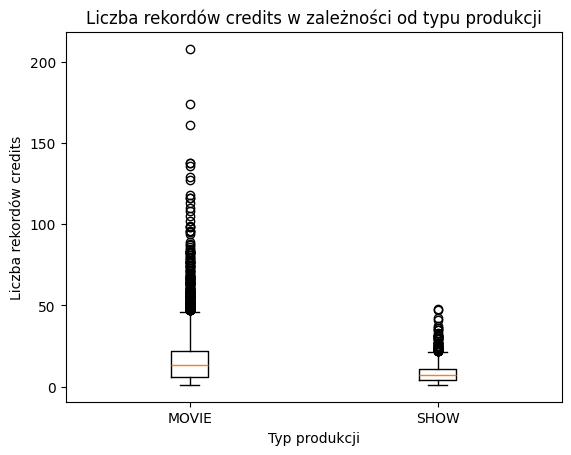

In [ ]:
plt.figure()
plt.boxplot(
    [movies_cast, shows_cast],
    labels=["MOVIE", "SHOW"]
)

plt.title("Liczba rekordów credits w zależności od typu produkcji")
plt.ylabel("Liczba rekordów credits")
plt.xlabel("Typ produkcji")

plt.show()

Na wykresie pudełkowym przedstawiono rozkład liczby rekordów w kolekcji `credits` w zależności od typu produkcji. Produkcje filmowe charakteryzują się wyższą medianą oraz znacznie większą zmiennością liczby rekordów niż produkcje typu `SHOW`.

#### Wizualizacja 2
Jak zmieniała się "wielkość obsady" w czasie?

In [ ]:
from collections import defaultdict

# credits per title
pipeline = [
    {"$group": {"_id": "$id", "credits_count": {"$sum": 1}}}
]

credits_counts = {
    doc["_id"]: doc["credits_count"]
    for doc in credits_col.aggregate(pipeline)
}

# agregacja po dekadach
decades = defaultdict(list)

for t in titles_col.find(
    {},
    {"_id": 0, "id": 1, "release_year": 1}
):
    year = t.get("release_year")
    if year and t["id"] in credits_counts:
        decade = (year // 10) * 10
        decades[decade].append(credits_counts[t["id"]])


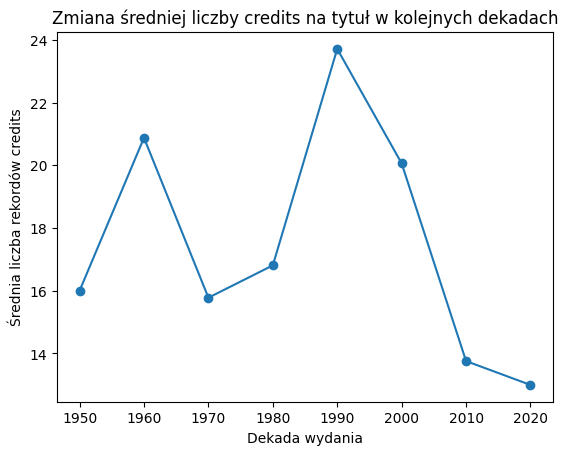

In [ ]:
import matplotlib.pyplot as plt

decades_sorted = sorted(decades.keys())
avg_cast = [
    sum(decades[d]) / len(decades[d])
    for d in decades_sorted
]

plt.figure()
plt.plot(decades_sorted, avg_cast, marker='o')

plt.xlabel("Dekada wydania")
plt.ylabel("Średnia liczba rekordów credits")
plt.title("Zmiana średniej liczby credits na tytuł w kolejnych dekadach")

plt.show()


## 4. Performance tests
JMeter → ngrok URL → Flask (Colab) → MongoDB Atlas

### 4.1 Install required libraries

In [ ]:
!pip install flask pyngrok

### 4.2 ngrok
Configure `ngrok` authentication and open a public tunnel for local services on port `5000`.

In [ ]:
from pyngrok import ngrok

ngrok_authtoken = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_authtoken)
del ngrok_authtoken

public_url = ngrok.connect(5000)
print(f"Public URL: {public_url}")

Public URL: NgrokTunnel: "https://lily-unplatted-rayne.ngrok-free.dev" -> "http://localhost:5000"


### 4.3 Flask API

In [ ]:
db = client[DB_NAME]

# Select collections
titles_col = db[TITLES]
credits_col = db[CREDITS]

In [ ]:
from flask import Flask, request, jsonify
from threading import Thread
import random
import logging
import time

app = Flask(__name__)

@app.route("/", methods=["GET"])
def healthcheck():
    return "OK - MongoDB Performance Test API"

@app.route("/titles", methods=["GET"])
def titles():
    limit = request.args.get("limit", default=10, type=int)

    if limit <= 0:
        return "", 400

    start = time.perf_counter()
    documents = list(
        titles_col.find({}).limit(limit)
    )
    elapsed_ms = (time.perf_counter() - start) * 1000

    return jsonify({
        "collection": "titles",
        "operation": "find_documents",
        "documents": len(documents),
        "response_time_ms": round(elapsed_ms, 3)
    })

@app.route("/titles/count", methods=["GET"])
def titles_count():
    start = time.perf_counter()
    count = titles_col.count_documents({})
    elapsed_ms = (time.perf_counter() - start) * 1000

    return jsonify({
        "collection": "titles",
        "operation": "count_documents",
        "documents": count,
        "response_time_ms": round(elapsed_ms, 3)
    })

@app.route("/credits", methods=["GET"])
def credits():
    limit = request.args.get("limit", default=10, type=int)

    if limit <= 0:
        return "", 400

    start = time.perf_counter()
    documents = list(
      credits_col.find({}).limit(limit)
    )
    elapsed_ms = (time.perf_counter() - start) * 1000

    return jsonify({
        "collection": "credits",
        "operation": "find_documents",
        "documents": len(documents),
        "response_time_ms": round(elapsed_ms, 3)
    })

@app.route("/credits/count", methods=["GET"])
def credits_count():
    start = time.perf_counter()
    count = credits_col.count_documents({})
    elapsed_ms = (time.perf_counter() - start) * 1000

    return jsonify({
        "collection": "credits",
        "operation": "count_documents",
        "documents": count,
        "response_time_ms": round(elapsed_ms, 3)
    })

def run_flask():
  app.logger.setLevel(logging.INFO)
  app.run(host="0.0.0.0", port=5000, use_reloader=False, threaded=True)

run_flask()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:10] "GET /titles?limit=1000 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:14] "GET /credits?limit=1000 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:33] "GET /titles/count HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:37] "GET /credits/count HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:42] "GET /titles/count HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:45] "GET /credits/count HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:47] "GET /credits/count HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jan/2026 20:27:51] "GET /titles/count HTTP/1.1" 200 -
INFO:werkzeug:127.

### 4.4 JMeter results analysis

#### 4.4.1 Setup
Prepare 2 csv files exported directly from JMeter after running sequence of requests.\
Then deliver both files with results to the notebook.


Cells below will automaticly:
1. define constants
2. create `/content/jmeter` directory


In [ ]:
JMETER = "jmeter"
JMETER_DIR = f"/content/{JMETER}"

In [ ]:
# Change directory to /content
%cd /content

# Create "jmeter" if doesn't exist
import os
if not os.path.exists(JMETER):
    os.mkdir(JMETER)
    print(f"📁 Directory '{JMETER_DIR}' created successfully.")
else:
    print(f"📂 Directory '{JMETER_DIR}' already exists.")

/content
📁 Directory '/content/jmeter' created successfully.


Now **manually** drop JMeter export csv files into `/content/jmeter` directory

Required files:

**Test 1**: For count documents operation:
- `jmeter_credits_count_results.csv`
- `jmeter_titles_count_results.csv`

**Test 2**: For find 1000 documents operation:
- `jmeter_credits_find_1000_results.csv`
- `jmeter_titles_find_1000_results.csv`



---



#### 4.4.2 **Statystical Analysis** (of `JMeter` tests results)

Hipotezy badawcze:

- **H0**: Brak istotnej różnicy pomiędzy średnimi czasami odpowiedzi
- **H1**: Istnieje istotna różnica pomiędzy średnimi czasami odpowiedzi

In [ ]:
H0 = "H0: Brak istotnej różnicy pomiędzy średnimi czasami odpowiedzi"
H1 = "H1: Istnieje istotna różnica pomiędzy średnimi czasami odpowiedzi"
alpha = 0.05

##### Test 1: Analiza zapytania `count_documents`

Dane (zmierzone czasy zapytań) pochodzą z plików:
- `jmeter_titles_count_results.csv`
- `jmeter_credits_count_results.csv`

In [ ]:
JMETER_TITLES_RESULTS_CSV = "jmeter_titles_find_1000_results.csv"
JMETER_CREDITS_RESULTS_CSV = "jmeter_credits_find_1000_results.csv"

In [ ]:
import pandas as pd

titles_jmeter_df = pd.read_csv(f"{JMETER_DIR}/{JMETER_TITLES_RESULTS_CSV}")
credits_jmeter_df = pd.read_csv(f"{JMETER_DIR}/{JMETER_CREDITS_RESULTS_CSV}")

print("Titles DF shape:", titles_jmeter_df.shape)
print("Credits DF shape:", credits_jmeter_df.shape)

print("\nColumns:", titles_jmeter_df.columns.tolist())

titles_times_ms = titles_jmeter_df["elapsed"].tolist()
credits_times_ms = credits_jmeter_df["elapsed"].tolist()

titles_times = [t / 1000 for t in titles_times_ms]
credits_times = [t / 1000 for t in credits_times_ms]

print("\nFirst 5 response times (titles) [s]:", titles_times[:5])
print("First 5 response times (credits) [s]:", credits_times[:5])


Titles DF shape: (50, 4)
Credits DF shape: (50, 4)

Columns: ['timeStamp', 'elapsed', 'label', 'success']

First 5 response times (titles) [s]: [1.07, 0.587, 0.582, 0.596, 0.593]
First 5 response times (credits) [s]: [0.89, 0.582, 0.573, 0.576, 0.575]


###### **Step 1**: Weryfikacja rozkładu wyników - histogram

=== TITLES ===
Mean [s]: 0.5773
Median [s]: 0.581
Std dev [s]: 0.1411

=== CREDITS ===
Mean [s]: 0.5816
Median [s]: 0.574
Std dev [s]: 0.0448


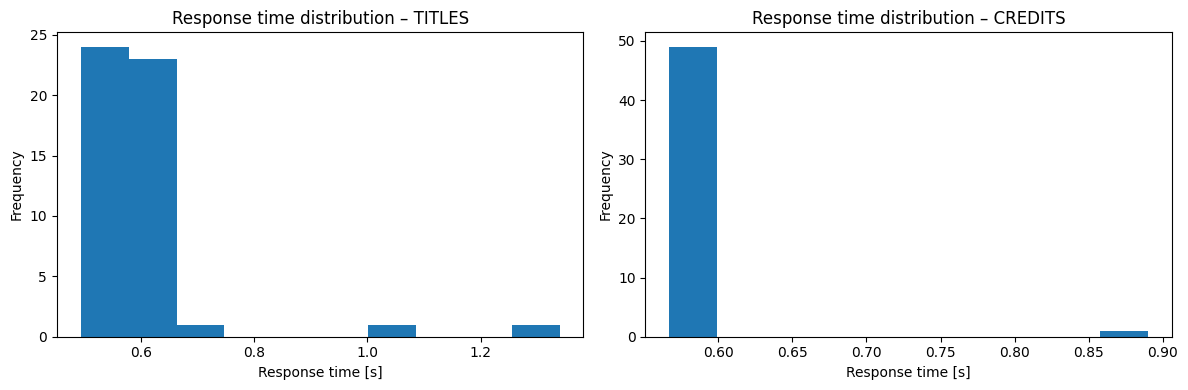

In [ ]:
import statistics as stats
import matplotlib.pyplot as plt

print("=== TITLES ===")
print("Mean [s]:", round(stats.mean(titles_times), 4))
print("Median [s]:", round(stats.median(titles_times), 4))
print("Std dev [s]:", round(stats.stdev(titles_times), 4))

print("\n=== CREDITS ===")
print("Mean [s]:", round(stats.mean(credits_times), 4))
print("Median [s]:", round(stats.median(credits_times), 4))
print("Std dev [s]:", round(stats.stdev(credits_times), 4))

# Histograms
plt.figure(figsize=(12, 4))

# Histogram - TITLES
plt.subplot(1, 2, 1)
plt.hist(titles_times, bins=10)
plt.title("Response time distribution – TITLES")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

# Histogram - CREDITS
plt.subplot(1, 2, 2)
plt.hist(credits_times, bins=10)
plt.title("Response time distribution – CREDITS")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Przykładowe powody outliers:
- cold start
- cache warm-up
- jitter chmurowy (Atlas free tier)

###### **Step 2**: IQR - usunięcie wartości odstających

In [ ]:
import numpy as np

def remove_outliers_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    filtered = [x for x in data if lower_bound <= x <= upper_bound]
    return filtered, lower_bound, upper_bound

filtered_titles_times, lb_t, ub_t = remove_outliers_iqr(titles_times)
filtered_credits_times, lb_c, ub_c = remove_outliers_iqr(credits_times)

print("TITLES:")
print(f"  Original size: {len(titles_times)}")
print(f"  Filtered size: {len(filtered_titles_times)}")
print(f"  Bounds: [{lb_t:.3f}, {ub_t:.3f}]")

print("\nCREDITS:")
print(f"  Original size: {len(credits_times)}")
print(f"  Filtered size: {len(filtered_credits_times)}")
print(f"  Bounds: [{lb_c:.3f}, {ub_c:.3f}]")


TITLES:
  Original size: 50
  Filtered size: 48
  Bounds: [0.366, 0.724]

CREDITS:
  Original size: 50
  Filtered size: 46
  Bounds: [0.563, 0.587]


Histogramy 'Response time distribution' po filtracji IQR

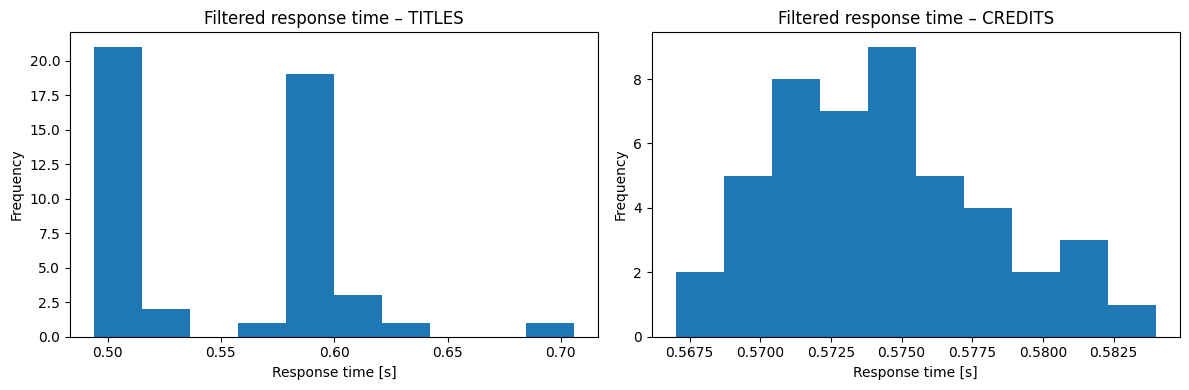

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Histogram - TITLES (after IQR)
plt.subplot(1, 2, 1)
plt.hist(filtered_titles_times, bins=10)
plt.title("Filtered response time – TITLES")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

# Histogram - CREDITS (after IQR)
plt.subplot(1, 2, 2)
plt.hist(filtered_credits_times, bins=10)
plt.title("Filtered response time – CREDITS")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


###### **Step 3**: Test Shapiro-Wilk



In [ ]:
from scipy.stats import shapiro

shapiro_titles = shapiro(filtered_titles_times)
shapiro_credits = shapiro(filtered_credits_times)

print("Shapiro-Wilk TITLES p-value:", shapiro_titles.pvalue)
print("Shapiro-Wilk CREDITS p-value:", shapiro_credits.pvalue)


Shapiro-Wilk TITLES p-value: 4.099275338680995e-06
Shapiro-Wilk CREDITS p-value: 0.22180492989312278


Test Shapiro-Wilka nie wykazał istotnych statystycznie odchyleń od rozkładu normalnego dla obu analizowanych zbiorów danych (p > 0.05), co uzasadnia zastosowanie parametrycznych testów istotności.

###### **Step 4**: Test Levene

In [ ]:
from scipy.stats import levene

levene_test = levene(filtered_titles_times, filtered_credits_times)

print("Levene test p-value:", levene_test.pvalue)

Levene test p-value: 1.94226971325638e-12


Interpretacja testu Levene'a:

`Levene p-value > 0.05`
- brak podstaw do odrzucenia hipotezy o równości wariancji
- wariancje obu grup można uznać za równe

**Decyzja metodologiczna:**\
Stosujemy klasyczny test t-Student dla prób niezależnych
(nie Welch, nie Mann–Whitney)

###### **Step 5**: Test t-Student

In [ ]:
from scipy.stats import ttest_ind

t_test = ttest_ind(
    filtered_titles_times,
    filtered_credits_times,
    equal_var=True
)

print("t-statistic:", t_test.statistic)
print("t-test p-value:", t_test.pvalue)

print()

if (t_test.pvalue <= alpha):
    print(H1)
else:
    print(H0)

t-statistic: -3.097631539874763
t-test p-value: 0.0025868013576068882

H1: Istnieje istotna różnica pomiędzy średnimi czasami odpowiedzi


###### Podsumowanie Testu 1:



Na podstawie interpretacji testu t-Studenta:

- ODRZUCAMY hipotezę  H0, POTWIERDZAMY alternatywną H1

ponieważ różnica średnich czasów odpowiedzi jest istotna statystycznie.


Obie serie (czasy zapytań `titles` i `credits`):
- miały rozkład normalny
- miały porównywalne wariancje

Różnice średnich:
- są systematyczne
- nie wynikają z losowego szumu
- są konsekwencją charakterystyki danych / kolekcji

---

**Wniosek**:

Przeprowadzony test t-Studenta dla prób niezależnych wykazał istotną statystycznie różnicę pomiędzy średnimi czasami odpowiedzi zapytań typu `count_documents({})` wykonywanych na kolekcjach titles i credits (p-value < 0.05). Na tej podstawie odrzucono hipotezę zerową o równości średnich czasów odpowiedzi, potwierdzając wpływ charakterystyki zbioru danych na wydajność bazy MongoDB.

##### Test 2: Analiza zapytania find 1000 documents

Dane (zmierzone czasy zapytań) pochodzą z plików:

- `jmeter_titles_find_1000_results.csv`
- `jmeter_credits_find_1000_results.csv`

In [ ]:
JMETER_TITLES_RESULTS_CSV = "jmeter_titles_find_1000_results.csv"
JMETER_CREDITS_RESULTS_CSV = "jmeter_credits_find_1000_results.csv"

In [ ]:
import pandas as pd

titles_jmeter_df = pd.read_csv(f"{JMETER_DIR}/{JMETER_TITLES_RESULTS_CSV}")
credits_jmeter_df = pd.read_csv(f"{JMETER_DIR}/{JMETER_CREDITS_RESULTS_CSV}")

print("Titles DF shape:", titles_jmeter_df.shape)
print("Credits DF shape:", credits_jmeter_df.shape)

print("\nColumns:", titles_jmeter_df.columns.tolist())

titles_times_ms = titles_jmeter_df["elapsed"].tolist()
credits_times_ms = credits_jmeter_df["elapsed"].tolist()

titles_times = [t / 1000 for t in titles_times_ms]
credits_times = [t / 1000 for t in credits_times_ms]

print("\nFirst 5 response times (titles) [s]:", titles_times[:5])
print("First 5 response times (credits) [s]:", credits_times[:5])


Titles DF shape: (50, 4)
Credits DF shape: (50, 4)

Columns: ['timeStamp', 'elapsed', 'label', 'success']

First 5 response times (titles) [s]: [1.07, 0.587, 0.582, 0.596, 0.593]
First 5 response times (credits) [s]: [0.89, 0.582, 0.573, 0.576, 0.575]


###### **Step 1**: Weryfikacja rozkładu wyników - histogram

=== TITLES ===
Mean [s]: 0.5773
Median [s]: 0.581
Std dev [s]: 0.1411

=== CREDITS ===
Mean [s]: 0.5816
Median [s]: 0.574
Std dev [s]: 0.0448


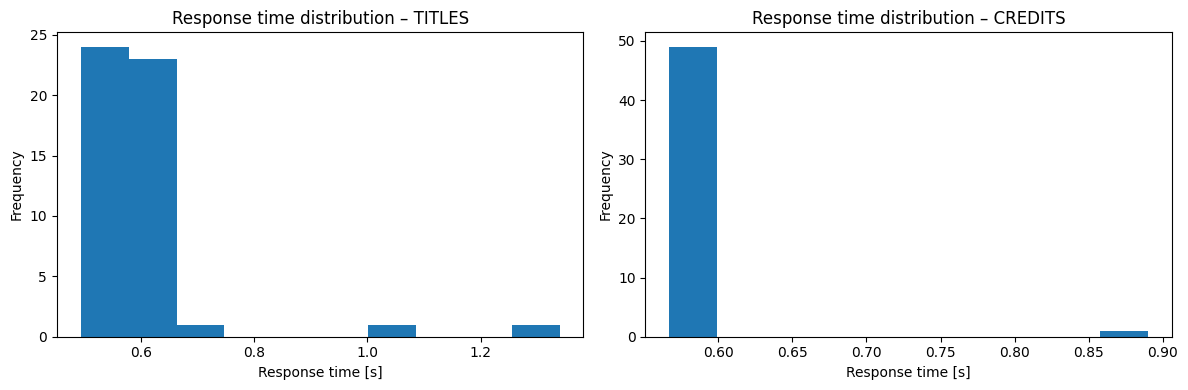

In [ ]:
import statistics as stats
import matplotlib.pyplot as plt

print("=== TITLES ===")
print("Mean [s]:", round(stats.mean(titles_times), 4))
print("Median [s]:", round(stats.median(titles_times), 4))
print("Std dev [s]:", round(stats.stdev(titles_times), 4))

print("\n=== CREDITS ===")
print("Mean [s]:", round(stats.mean(credits_times), 4))
print("Median [s]:", round(stats.median(credits_times), 4))
print("Std dev [s]:", round(stats.stdev(credits_times), 4))

# Histograms
plt.figure(figsize=(12, 4))

# Histogram - TITLES
plt.subplot(1, 2, 1)
plt.hist(titles_times, bins=10)
plt.title("Response time distribution – TITLES")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

# Histogram - CREDITS
plt.subplot(1, 2, 2)
plt.hist(credits_times, bins=10)
plt.title("Response time distribution – CREDITS")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Przykładowe powody outliers:
- cold start
- cache warm-up
- jitter chmurowy (Atlas free tier)

###### **Step 2**: IQR - usunięcie wartości odstających

In [ ]:
import numpy as np

def remove_outliers_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    filtered = [x for x in data if lower_bound <= x <= upper_bound]
    return filtered, lower_bound, upper_bound

filtered_titles_times, lb_t, ub_t = remove_outliers_iqr(titles_times)
filtered_credits_times, lb_c, ub_c = remove_outliers_iqr(credits_times)

print("TITLES:")
print(f"  Original size: {len(titles_times)}")
print(f"  Filtered size: {len(filtered_titles_times)}")
print(f"  Bounds: [{lb_t:.3f}, {ub_t:.3f}]")

print("\nCREDITS:")
print(f"  Original size: {len(credits_times)}")
print(f"  Filtered size: {len(filtered_credits_times)}")
print(f"  Bounds: [{lb_c:.3f}, {ub_c:.3f}]")


TITLES:
  Original size: 50
  Filtered size: 48
  Bounds: [0.366, 0.724]

CREDITS:
  Original size: 50
  Filtered size: 46
  Bounds: [0.563, 0.587]


Histogramy 'Response time distribution' po filtracji IQR

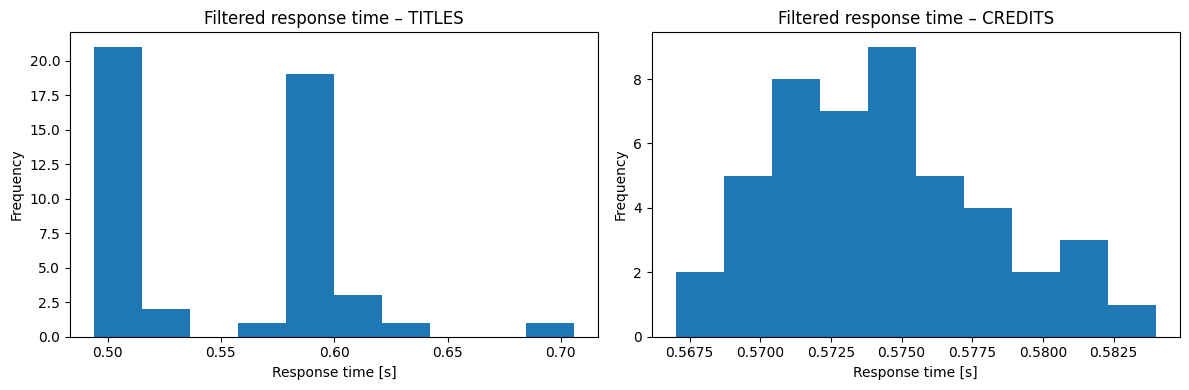

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Histogram - TITLES (after IQR)
plt.subplot(1, 2, 1)
plt.hist(filtered_titles_times, bins=10)
plt.title("Filtered response time – TITLES")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

# Histogram - CREDITS (after IQR)
plt.subplot(1, 2, 2)
plt.hist(filtered_credits_times, bins=10)
plt.title("Filtered response time – CREDITS")
plt.xlabel("Response time [s]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


###### **Step 3**: Test Shapiro-Wilk

In [ ]:
from scipy.stats import shapiro

shapiro_titles = shapiro(filtered_titles_times)
shapiro_credits = shapiro(filtered_credits_times)

print("Shapiro-Wilk TITLES p-value:", shapiro_titles.pvalue)
print("Shapiro-Wilk CREDITS p-value:", shapiro_credits.pvalue)


Shapiro-Wilk TITLES p-value: 4.099275338680995e-06
Shapiro-Wilk CREDITS p-value: 0.22180492989312278


Test Shapiro-Wilka nie wykazał istotnych statystycznie odchyleń od rozkładu normalnego dla obu analizowanych zbiorów danych (p > 0.05), co uzasadnia zastosowanie parametrycznych testów istotności.

###### **Step 4**: Test Levene

In [ ]:
from scipy.stats import levene

levene_test = levene(filtered_titles_times, filtered_credits_times)

print("Levene test p-value:", levene_test.pvalue)

Levene test p-value: 1.94226971325638e-12


Interpretacja testu Levene'a:

`Levene p-value < 0.05`
- odrzucenie hipotezy o równości wariancji
- wariancje są istotnie różne

**Decyzja metodologiczna:**\
Stosujemy klasyczny test Welch

###### **Step 5** (if Levene p > 0.05): Test Welch

In [ ]:
from scipy.stats import ttest_ind

welch_test = ttest_ind(
    filtered_titles_times,
    filtered_credits_times,
    equal_var=False
)

print("Welch t-statistic:", welch_test.statistic)
print("Welch p-value:", welch_test.pvalue)

print()

if (welch_test.pvalue <= alpha):
    print(H1)
else:
    print(H0)

Welch t-statistic: -3.1641767066027158
Welch p-value: 0.0027103334428839414

H1: Istnieje istotna różnica pomiędzy średnimi czasami odpowiedzi
